# Redshift Distribution

This notebook reads the DESI raw zone files from the local `data/edr/raw` folder and shows two versions of the redshift distribution: first raw counts, then the normalized distribution $N_{Gal} / \Delta Z$.


Zone: 0
Zone: 1
Zone: 2
Zone: 3
Zone: 4
Zone: 5
Zone: 6
Zone: 7
Zone: 8
Zone: 9
Zone: 10
Zone: 11
Zone: 12
Zone: 13
Zone: 14
Zone: 15
Zone: 16
Zone: 17
Zone: 18
Zone: 19
Total N_Gal per tracer (data):
BGS object: 241746
LRG object: 112649
ELG object: 267345
QSO object: 35566


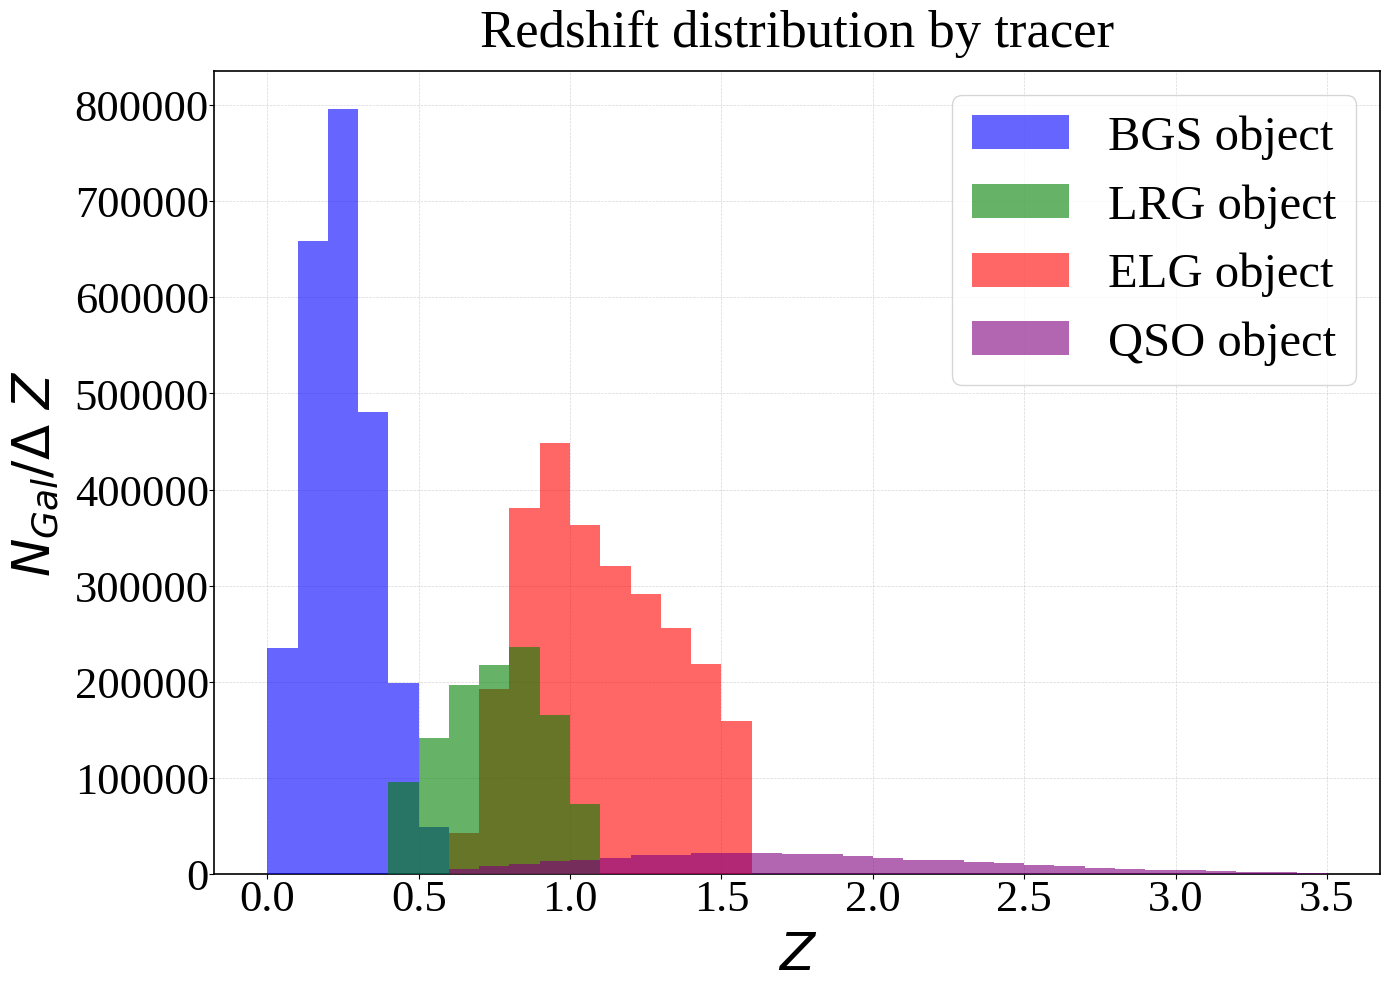

Zone: 0
Zone: 1
Zone: 2
Zone: 3
Zone: 4
Zone: 5
Zone: 6
Zone: 7
Zone: 8
Zone: 9
Zone: 10
Zone: 11
Zone: 12
Zone: 13
Zone: 14
Zone: 15
Zone: 16
Zone: 17
Zone: 18
Zone: 19
Total N_Gal per tracer (random):
BGS random: 24174600
LRG random: 11264900
ELG random: 26734500
QSO random: 3556600


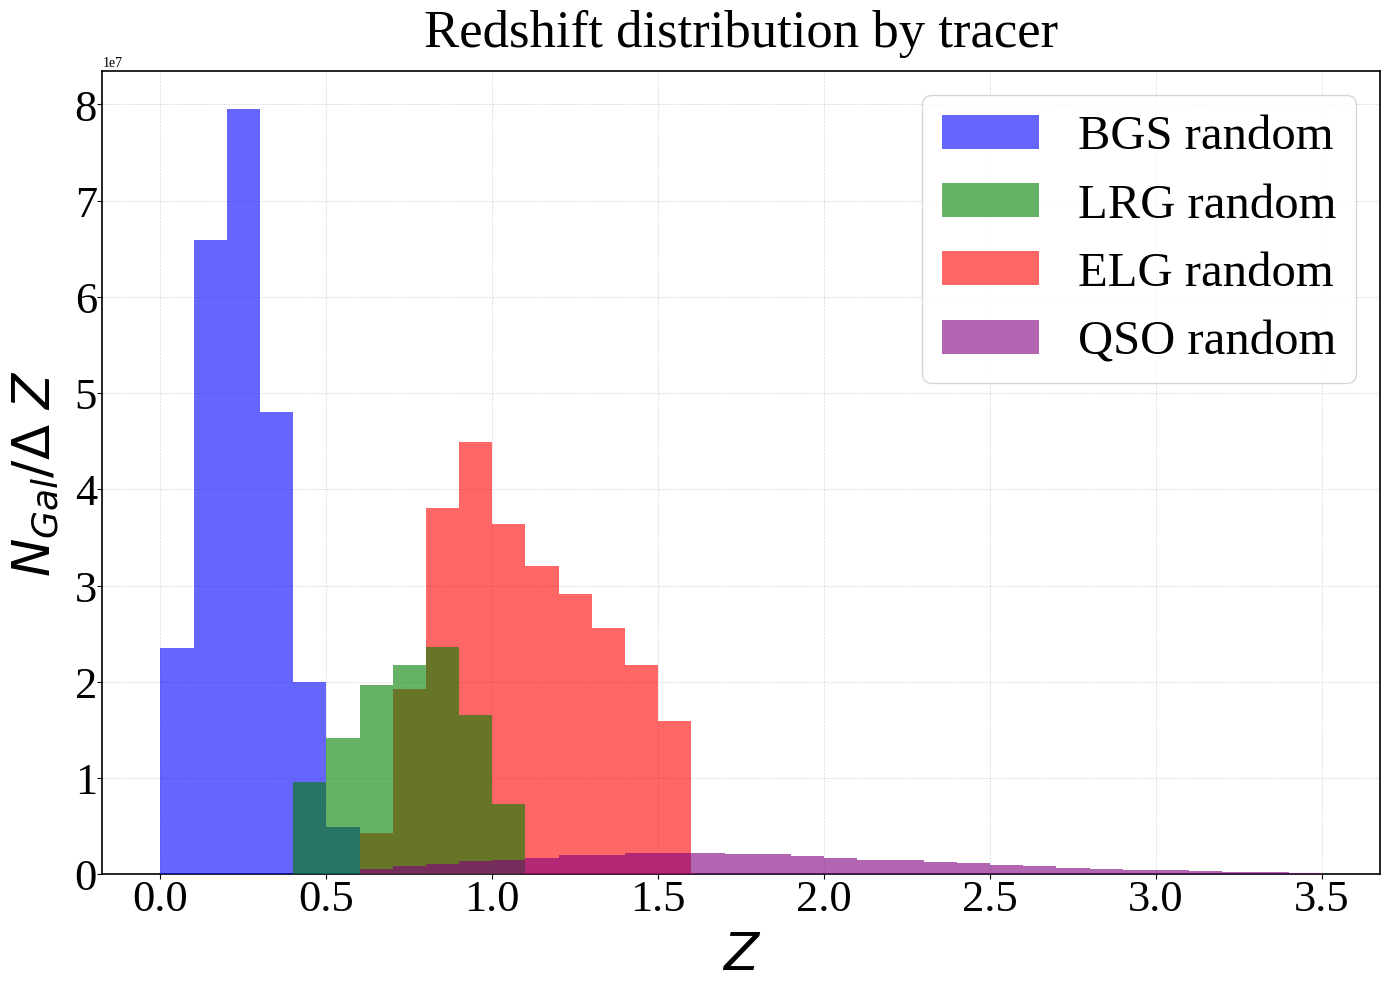

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

plt.rcParams["font.family"] = "Liberation Serif"
plt.rcParams["axes.linewidth"] = 1.2

RAW_DIR = Path("/Users/soguevaram/Desktop/Research/DESI/data/edr/raw")
PLOTS_DIR = Path("/Users/soguevaram/Desktop/Research/DESI/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
N_ZONES = 20
DELTA_Z = 0.1

TRACERS_DATA = ["BGS_ANY_DATA", "LRG_DATA", "ELG_DATA", "QSO_DATA"]
TRACERS_RAND = ["BGS_ANY_RAND", "LRG_RAND", "ELG_RAND", "QSO_RAND"]

TRACER_NAMES_DATA = {
    "BGS_ANY_DATA": "BGS object",
    "LRG_DATA": "LRG object",
    "ELG_DATA": "ELG object",
    "QSO_DATA": "QSO object",
}

TRACER_NAMES_RAND = {
    "BGS_ANY_RAND": "BGS random",
    "LRG_RAND": "LRG random",
    "ELG_RAND": "ELG random",
    "QSO_RAND": "QSO random",
}

TRACER_COLORS = {
    "BGS_ANY_DATA": "blue",
    "LRG_DATA": "green",
    "ELG_DATA": "red",
    "QSO_DATA": "purple",
    "BGS_ANY_RAND": "blue",
    "LRG_RAND": "green",
    "ELG_RAND": "red",
    "QSO_RAND": "purple",
}

TRACER_ZORDER = {
    "BGS_ANY_DATA": 3,
    "ELG_DATA": 4,
    "LRG_DATA": 5,
    "QSO_DATA": 6,
    "BGS_ANY_RAND": 3,
    "ELG_RAND": 4,
    "LRG_RAND": 5,
    "QSO_RAND": 6,
}


def load_zone(zone):
    path = RAW_DIR / f"zone_{zone:02d}.fits.gz"
    table = Table.read(path)
    df = table.to_pandas()

    for col in df.columns:
        df[col] = df[col].apply(lambda x: x.decode() if isinstance(x, bytes) else x)

    return df



def collect_redshift_values(tracers):
    data_dict = {tr: [] for tr in tracers}

    for zone in range(N_ZONES):
        print(f"Zone: {zone}")
        zone_df = load_zone(zone)

        for tr in tracers:
            zvals = zone_df.loc[zone_df["TRACERTYPE"] == tr, "Z"].to_numpy()
            if zvals.size > 0:
                data_dict[tr].append(zvals)

    for tr in tracers:
        if data_dict[tr]:
            data_dict[tr] = np.concatenate(data_dict[tr])
        else:
            data_dict[tr] = np.array([])

    return data_dict



def plot_redshift_distribution(data_dict, tracer_names, title, save_path, normalize=False):
    fig, ax = plt.subplots(figsize=(14, 10))

    all_values = [vals for vals in data_dict.values() if vals.size > 0]
    if not all_values:
        raise ValueError("No redshift values were found for the selected tracers.")

    z_min = min(vals.min() for vals in all_values)
    z_max = max(vals.max() for vals in all_values)
    start = np.floor(z_min / DELTA_Z) * DELTA_Z
    stop = np.ceil(z_max / DELTA_Z) * DELTA_Z
    edges = np.arange(start, stop + DELTA_Z, DELTA_Z)
    widths = np.diff(edges)
    centers = 0.5 * (edges[:-1] + edges[1:])

    for tracer, zvals in data_dict.items():
        if zvals.size == 0:
            continue

        counts, _ = np.histogram(zvals, bins=edges)
        heights = counts / widths if normalize else counts

        ax.bar(
            centers,
            heights,
            width=widths,
            alpha=0.6,
            align="center",
            label=tracer_names[tracer],
            color=TRACER_COLORS.get(tracer, "gray"),
            zorder=TRACER_ZORDER.get(tracer, 1),
        )

    ax.set_xlabel(r"$Z$", fontsize=37, labelpad=10)
    if normalize:
        ax.set_ylabel(r"$N_{Gal} / \Delta~Z$", fontsize=37, labelpad=10)
    else:
        ax.set_ylabel(r"$N_{Gal}$", fontsize=37)
    ax.set_title(title, fontsize=38, y=1.02)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)
    ax.legend(fontsize=35)
    ax.tick_params(axis="both", labelsize=32, pad=0.4)

    plt.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


data_dict = collect_redshift_values(TRACERS_DATA)
print("Total N_Gal per tracer (data):")
for tracer in TRACERS_DATA:
    print(f"{TRACER_NAMES_DATA[tracer]}: {len(data_dict[tracer])}")
plot_redshift_distribution(
    data_dict,
    TRACER_NAMES_DATA,
    "Redshift distribution by tracer",
    PLOTS_DIR / "redshift_data.png",
    normalize=True,
)

rand_dict = collect_redshift_values(TRACERS_RAND)
print("Total N_Gal per tracer (random):")
for tracer in TRACERS_RAND:
    print(f"{TRACER_NAMES_RAND[tracer]}: {len(rand_dict[tracer])}")
plot_redshift_distribution(
    rand_dict,
    TRACER_NAMES_RAND,
    "Redshift distribution by tracer",
    PLOTS_DIR / "redshift_random.png",
    normalize=True,
)
